# Youtube Spam Comment Detection

In this notebook, I will be building a model to detect spam comments on youtube using a dataset containing some of the comments from a couple of famous music videos. The data itself is taken from Kaggle but scraped from the youtube comment section itself

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import re
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
import scipy.sparse as sp
from scipy.sparse import hstack
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import precision_score, accuracy_score, recall_score
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# Download the dictionary files that lemmatization needs
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

## Dataset Reading


In this part I'm loading the data and naming it to something simple.
Class = Spam (1) or Not Spam (0)

In [2]:
YTspam = pd.read_csv('Youtube-Spam-Dataset.csv')
YTspam.head(10)

,COMMENT_ID,AUTHOR,DATE,CONTENT,VIDEO_NAME,CLASS
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",PSY - GANGNAM STYLE(?????) M/V,1
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,PSY - GANGNAM STYLE(?????) M/V,1
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,PSY - GANGNAM STYLE(?????) M/V,1
3,z13jhp0bxqncu512g22wvzkasxmvvzjaz04,ElNino Melendez,2013-11-09T08:28:43,me shaking my sexy ass on my channel enjoy ^_^ ﻿,PSY - GANGNAM STYLE(?????) M/V,1
4,z13fwbwp1oujthgqj04chlngpvzmtt3r3dw,GsMega,2013-11-10T16:05:38,watch?v=vtaRGgvGtWQ Check this out .﻿,PSY - GANGNAM STYLE(?????) M/V,1
5,LZQPQhLyRh9-wNRtlZDM90f1k0BrdVdJyN_YsaSwfxc,Jason Haddad,2013-11-26T02:55:11,"Hey, check out my new website!! This site is a...",PSY - GANGNAM STYLE(?????) M/V,1
6,z13lfzdo5vmdi1cm123te5uz2mqig1brz04,ferleck ferles,2013-11-27T21:39:24,Subscribe to my channel ﻿,PSY - GANGNAM STYLE(?????) M/V,1
7,z122wfnzgt30fhubn04cdn3xfx2mxzngsl40k,Bob Kanowski,2013-11-28T12:33:27,i turned it on mute as soon is i came on i jus...,PSY - GANGNAM STYLE(?????) M/V,0
8,z13ttt1jcraqexk2o234ghbgzxymz1zzi04,Cony,2013-11-28T16:01:47,You should check my channel for Funny VIDEOS!!﻿,PSY - GANGNAM STYLE(?????) M/V,1
9,z12avveb4xqiirsix04chxviiljryduwxg0,BeBe Burkey,2013-11-28T16:30:13,and u should.d check my channel and tell me wh...,PSY - GANGNAM STYLE(?????) M/V,1


## Data cleaning

In this section I'll be making sure that the included data is useful and there are no duplicates that can mess up the end results.

### Dropping Duplicates

Before I drop the duplicates, I want to actually look at what these duplicate comments look like first. In my domain analysis I mentioned that spam bots often post the exact same templated message across multiple accounts, so viewing these duplicates before removing them could be interesting to see.

In [3]:
# First let's view the duplicate comments before removing them
duplicates = YTspam[YTspam.duplicated(subset=['CONTENT'], keep=False)].copy()
print(f"Total duplicate comment entries: {len(duplicates)}")
print(f"Unique duplicated messages: {duplicates['CONTENT'].nunique()}")
duplicates[['AUTHOR', 'CONTENT', 'CLASS']].sort_values('CONTENT').head(20)

Total duplicate comment entries: 255
Unique duplicated messages: 59


,AUTHOR,CONTENT,CLASS
1248,Adela Korman,Check out my SEXY VIDEO :*,1
1249,Adela Korman,Check out my SEXY VIDEO :*,1
1245,real money,subscribe to my feed,1
1763,real money,subscribe to my feed,1
1910,ricky swaggz,******* Facebook is LAME and so 2004! Check ou...,1
1929,ricky swaggz,******* Facebook is LAME and so 2004! Check ou...,1
1945,ThirdDegr3e,**CHECK OUT MY NEW MIXTAPE**** **CHECK OUT MY ...,1
1946,ThirdDegr3e,**CHECK OUT MY NEW MIXTAPE**** **CHECK OUT MY ...,1
1947,ThirdDegr3e,**CHECK OUT MY NEW MIXTAPE**** **CHECK OUT MY ...,1
1821,ben mashall,:),0


So looking at it, the duplicates are literally the same comment posted by same or different authors — which is exactly the bot farm behavior I talked about in my domain analysis. You can see spam bots using different accounts but copy-pasting the exact same message. Now that I've confirmed this, I'll drop them since keeping them would just bias the model toward those specific phrases.

In [4]:
# Quick check: are most duplicates spam or real?
dup_class_dist = duplicates['CLASS'].value_counts()
dup_labels = {0: 'Real', 1: 'Spam'}
print("Class distribution of duplicate comments:")
for cls, count in dup_class_dist.items():
    print(f"  {dup_labels[cls]}: {count} ({count/len(duplicates)*100:.1f}%)")

Class distribution of duplicate comments:
  Spam: 200 (78.4%)
  Real: 55 (21.6%)


As expected, the overwhelming majority of duplicates are spam, which confirms that these are bot-driven copies and not just real fans coincidentally writing the same thing. Now dropping them is justified.

In [5]:
# Now removing the duplicates since we've confirmed what they are
YTspam.drop_duplicates(subset=['CONTENT'], inplace=True)
YTspam.info()

<class 'pandas.DataFrame'>
Index: 1760 entries, 0 to 1955
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   COMMENT_ID  1760 non-null   str  
 1   AUTHOR      1760 non-null   str  
 2   DATE        1553 non-null   str  
 3   CONTENT     1760 non-null   str  
 4   VIDEO_NAME  1760 non-null   str  
 5   CLASS       1760 non-null   int64
dtypes: int64(1), str(5)
memory usage: 445.7 KB


### Missing Values Check

I will be checking and handling the missing values in the dataset, focusing on the date column since it will be used to find behavioral patterns

In [6]:
YTspam.isnull().sum()

COMMENT_ID      0
AUTHOR          0
DATE          207
CONTENT         0
VIDEO_NAME      0
CLASS           0
dtype: int64

In [7]:
# Dropping empty dates
YTspam.dropna(subset=['DATE'], inplace=True)
YTspam.info()

<class 'pandas.DataFrame'>
Index: 1553 entries, 0 to 1955
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   COMMENT_ID  1553 non-null   str  
 1   AUTHOR      1553 non-null   str  
 2   DATE        1553 non-null   str  
 3   CONTENT     1553 non-null   str  
 4   VIDEO_NAME  1553 non-null   str  
 5   CLASS       1553 non-null   int64
dtypes: int64(1), str(5)
memory usage: 376.8 KB


### Pre-Filter Duplicate Detector

So now that I've cleaned the duplicates out of the dataset, I want to actually build something useful out of what I found. Since those bot clusters are literally copy-pasting the same message, I can build a lightweight pre-filter that catches those identical comments instantly before even running them through the ML model. Think of it as the first line of defense: cheap, instant, no AI needed.

In [8]:
# 1. Find all comments that appear more than once across the original data
#    We reload to check before de-duplication was applied, so we count original frequencies
dup_content_counts = pd.read_csv('Youtube-Spam-Dataset.csv')['CONTENT'].value_counts()
repeated = dup_content_counts[dup_content_counts > 1]

print(f"Unique messages that appear more than once: {len(repeated)}")
print(f"Total duplicate entries those account for: {repeated.sum() - len(repeated)}")
print()

# 2. Cross-reference with CLASS to confirm they're mostly spam
dup_check = pd.read_csv('Youtube-Spam-Dataset.csv')
dup_check = dup_check[dup_check['CONTENT'].isin(repeated.index)]
dup_spam_pct = dup_check.groupby('CONTENT')['CLASS'].mean()

spam_clusters = dup_spam_pct[dup_spam_pct >= 0.8]
print(f"Bot clusters (80%+ spam rate): {len(spam_clusters)}")
print(f"Real fan phrase clusters (mostly real): {(dup_spam_pct < 0.5).sum()}")

Unique messages that appear more than once: 59
Total duplicate entries those account for: 196

Bot clusters (80%+ spam rate): 36
Real fan phrase clusters (mostly real): 23


So the majority of repeated messages are spam clusters are confirmed bot behavior. Now I'll build the actual pre-filter as a simple Python function. In production this would be the thing that runs first before any model, instantly banning known bot phrases.

In [9]:
# 3. Build the pre-filter: a set of known spam phrases extracted from duplicate clusters
SPAM_PREFILTER = set(spam_clusters.index.str.lower().str.strip())

def prefilter_check(comment):
    """
    Instant string-match pre-filter.
    Returns True if the comment is a known bot phrase, False if it needs ML evaluation.
    """
    return comment.lower().strip() in SPAM_PREFILTER

# Quick demo
test_comments = [
    "this song is so amazing love it",
    "Check out my channel! Subscribe for FREE music!",
]

print("Pre-filter demo:")
print("-" * 40)
for c in test_comments:
    result = prefilter_check(c)
    verdict = "BLOCKED by pre-filter (known bot phrase)" if result else "Passed to ML model for evaluation"
    print(f"Comment : {c[:60]}")
    print(f"Verdict : {verdict}")
    print()

Pre-filter demo:
----------------------------------------
Comment : this song is so amazing love it
Verdict : Passed to ML model for evaluation

Comment : Check out my channel! Subscribe for FREE music!
Verdict : Passed to ML model for evaluation



The pre-filter works by keeping a set of known spam phrases extracted from the duplicate analysis. Any comment that matches gets blocked instantly without touching the model at all — which is useful in production where speed matters. Everything else gets passed down to the full ML pipeline.

## EDA

In this section I'm analyzing the dataset using visualization such as graphs or tables to view if the dataset is balance and to see if there are biases and weird features.

### Target Distribution Check

I will be looking on how balance my target variable is by viewing the 'CLASS' feature from the dataset. (1 is Spam, 0 is Not Spam)

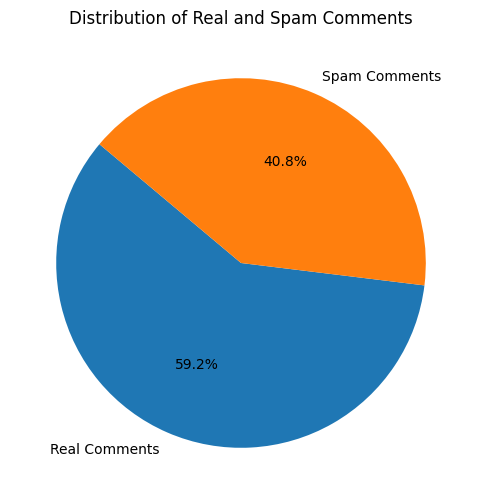

In [10]:
# Counting the number of instances in each class
class_count =YTspam['CLASS'].value_counts()

# Labelling the classes
class_labels = {0: 'Real Comments', 1: 'Spam Comments'}

# Plotting the class distribution
plt.figure(figsize=(8, 6))
plt.pie(class_count, labels=[class_labels[i] for i in class_count.index], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Real and Spam Comments') 
plt.show()



So the split is roughly 60% to 40%, which means though it's not fully balanced, there is still a lot of ratio of spam comments to train our models.

### Viewing the Length of The Comments

In my domain analysis I found that there are certain behaviour that spam comments have, majority of it is either super long or super short. In this section I'll be viewing if that's true for this dataset

In [11]:
# New column to view length of comments
YTspam['COMMENT_LENGTH'] = YTspam['CONTENT'].str.len()
YTspam.head(10)

,COMMENT_ID,AUTHOR,DATE,CONTENT,VIDEO_NAME,CLASS,COMMENT_LENGTH
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",PSY - GANGNAM STYLE(?????) M/V,1,56
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,PSY - GANGNAM STYLE(?????) M/V,1,166
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,PSY - GANGNAM STYLE(?????) M/V,1,38
3,z13jhp0bxqncu512g22wvzkasxmvvzjaz04,ElNino Melendez,2013-11-09T08:28:43,me shaking my sexy ass on my channel enjoy ^_^ ﻿,PSY - GANGNAM STYLE(?????) M/V,1,48
4,z13fwbwp1oujthgqj04chlngpvzmtt3r3dw,GsMega,2013-11-10T16:05:38,watch?v=vtaRGgvGtWQ Check this out .﻿,PSY - GANGNAM STYLE(?????) M/V,1,39
5,LZQPQhLyRh9-wNRtlZDM90f1k0BrdVdJyN_YsaSwfxc,Jason Haddad,2013-11-26T02:55:11,"Hey, check out my new website!! This site is a...",PSY - GANGNAM STYLE(?????) M/V,1,82
6,z13lfzdo5vmdi1cm123te5uz2mqig1brz04,ferleck ferles,2013-11-27T21:39:24,Subscribe to my channel ﻿,PSY - GANGNAM STYLE(?????) M/V,1,25
7,z122wfnzgt30fhubn04cdn3xfx2mxzngsl40k,Bob Kanowski,2013-11-28T12:33:27,i turned it on mute as soon is i came on i jus...,PSY - GANGNAM STYLE(?????) M/V,0,78
8,z13ttt1jcraqexk2o234ghbgzxymz1zzi04,Cony,2013-11-28T16:01:47,You should check my channel for Funny VIDEOS!!﻿,PSY - GANGNAM STYLE(?????) M/V,1,47
9,z12avveb4xqiirsix04chxviiljryduwxg0,BeBe Burkey,2013-11-28T16:30:13,and u should.d check my channel and tell me wh...,PSY - GANGNAM STYLE(?????) M/V,1,67


C:\Users\Ananda Wira\AppData\Local\Temp\ipykernel_27020\864454105.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CLASS', y='COMMENT_LENGTH', data=YTspam, palette=['skyblue', 'salmon'])


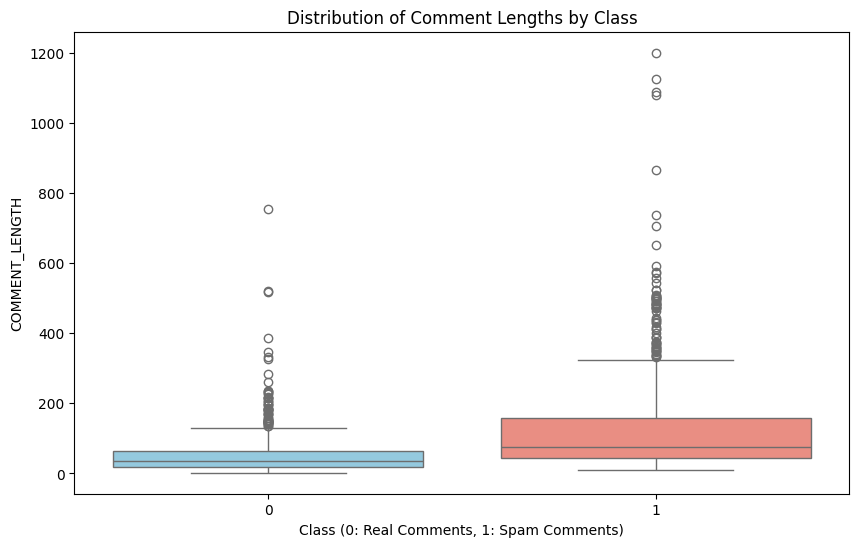

In [12]:
# Boxplot to visualize the distribution of comment lengths for real and spam comments
plt.figure(figsize=(10, 6))
sns.boxplot(x='CLASS', y='COMMENT_LENGTH', data=YTspam, palette=['skyblue', 'salmon'])

#Labellint the axes and title
plt.xlabel('Class (0: Real Comments, 1: Spam Comments)')
plt.title('Distribution of Comment Lengths by Class')
plt.show()

As we can see it's true that spam comments can be very long and noisy, while some of it can also be very short. Majority of it is longer than the real comments

### URL Links In spam comments

Again in my domain understanding I found out that spam comments has a lot of URL promotion links or phising links in it, this section is viewing if that is true or not.

In [13]:
# checking for links in the comments
YTspam['HAS_LINK'] =  YTspam['CONTENT'].str.contains('http|www', case=False, regex=True)
pd.crosstab(YTspam['CLASS'], YTspam['HAS_LINK'])

HAS_LINK,False,True
CLASS,,
0,910,9
1,450,184


So from the result we can conclude, though the presence of URL links are not in the majority of comments, it is mostly in the spam ones (184).

### Call-to-Action Check

In my domain understanding, I state that a lot of spam comments are generic and call to action phrases like "subscribe", "giveaway", "whatsapp". All of these I will be looking into in this section, this finding could affect the final results of the training.

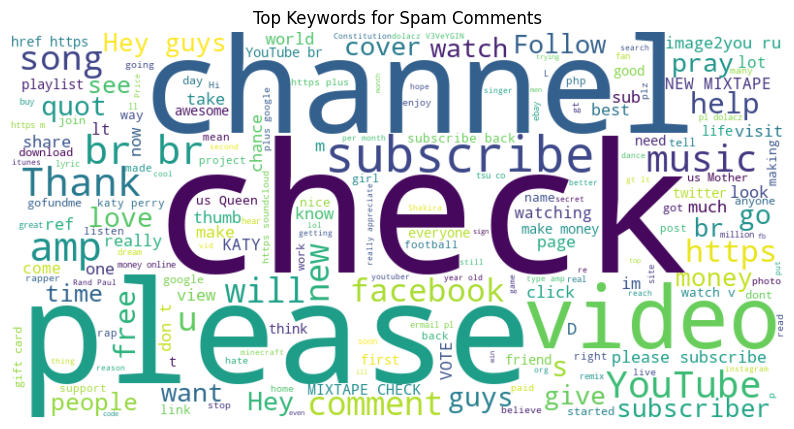

In [14]:
from wordcloud import WordCloud, STOPWORDS

# Combining all spam comments into a single string
spam_comments = ' '.join(YTspam[YTspam['CLASS'] == 1]['CONTENT'])

#Generate the word cloud for spam comments
spam_wc = WordCloud(stopwords=STOPWORDS, background_color='white', width=800, height=400).generate(spam_comments)

# Display the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Top Keywords for Spam Comments')
plt.show()

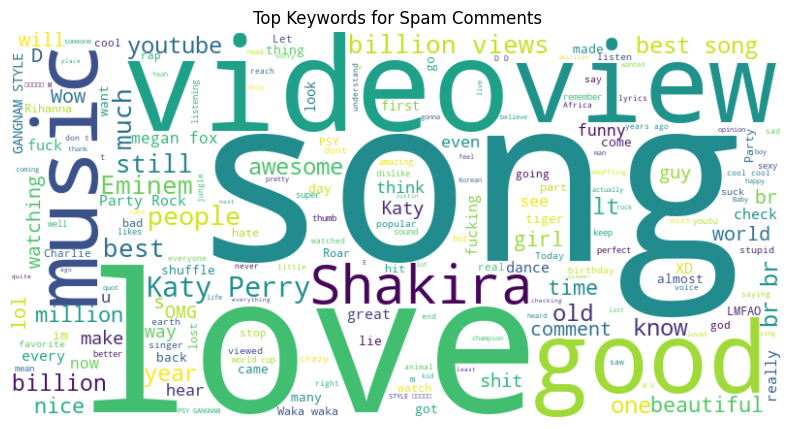

In [15]:
# Combining all real comments into a single string
real_comments = ' '.join(YTspam[YTspam['CLASS'] == 0]['CONTENT'])

#Generate the word cloud for real comments
real_wc = WordCloud(stopwords=STOPWORDS, background_color='white', width=800, height=400).generate(real_comments)

# Display the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(real_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Top Keywords for Spam Comments')
plt.show()

So we can conclude that the difference between real and spam comments on this matter is that spams usually write something irrelevant to the videos while real comments focus more on video, experience, specific details like the artists.

## Capitalization Ratio and Punctuation Count


In my domain analysis I stated that Spam comments have traits of doing caps lock words like "COMMENT" and also intese punctuation like "COMMENT!!!!!" or "RIGHT???????". In this section I will be trying to prove if it actually behaves as stated.

C:\Users\Ananda Wira\AppData\Local\Temp\ipykernel_27020\2716434837.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CLASS', y='CAPITALIZATION_RATIO', data=YTspam, palette=['skyblue', 'salmon'])
C:\Users\Ananda Wira\AppData\Local\Temp\ipykernel_27020\2716434837.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CLASS', y='PUNC_DENSITY', data=YTspam, palette=['skyblue', 'salmon'])


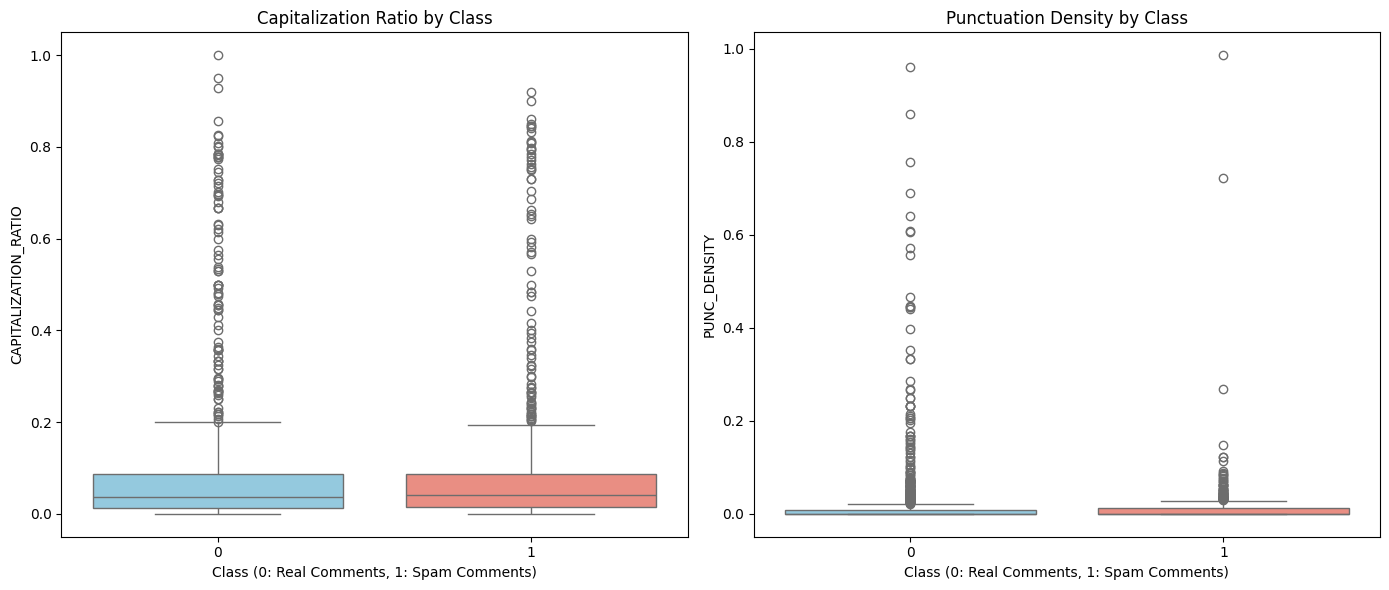

In [16]:
# Capitalization Ratio 
YTspam['CAPITALIZATION_RATIO'] = YTspam['CONTENT'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)

# Punctuation Density (Focus on "!" and "?" as they are common in spam comments)
# Counting how often these punctuation marks appear in each comment
YTspam['PUNC_COUNT'] = YTspam['CONTENT'].str.count('[!?]')

# Calculating punctuation density as the count of "!" and "?" per character
YTspam['PUNC_DENSITY'] = YTspam.apply(lambda row: row['PUNC_COUNT'] / row['COMMENT_LENGTH'] if row['COMMENT_LENGTH'] > 0 else 0, axis=1)

# Visualize side by side boxplots for capitalization ratio and punctuation density
plt.figure(figsize=(14, 6))
# Boxplot for Capitalization Ratio
plt.subplot(1, 2, 1)
sns.boxplot(x='CLASS', y='CAPITALIZATION_RATIO', data=YTspam, palette=['skyblue', 'salmon'])
plt.xlabel('Class (0: Real Comments, 1: Spam Comments)')
plt.title('Capitalization Ratio by Class')
# Boxplot for Punctuation Density
plt.subplot(1, 2, 2)
sns.boxplot(x='CLASS', y='PUNC_DENSITY', data=YTspam, palette=['skyblue', 'salmon'])
plt.xlabel('Class (0: Real Comments, 1: Spam Comments)')
plt.title('Punctuation Density by Class') 
plt.tight_layout()

plt.show()

Based on the graph we have, we can conclude that this is a weak feature and basically more of a noise if I decided to use this. So for this dataset it's been proven that this feature will not be used.

## Character Obfuscation


In my domain understanding, Character Obfuscation is where spam comments try to hinde that they are bots by adding things into the word like "s-u-b-s" or "s.u.b.s" and other similar stuff. I'll be trying to prove if it's a relevant thing to consider here.

In [17]:
# This looks for letters separated by dots, dashes, or underscores
# Example: s.u.b or s-u-b
obfuscation_pattern = r'([a-zA-Z][.\-_]){2,}'

# see if any comments match this pattern
matches = YTspam[YTspam['CONTENT'].str.contains(obfuscation_pattern, regex=True, na=False)]

print(f"Found {len(matches)} comments with potential character obfuscation.")

# Displaying a few examples of comments that match the obfuscation pattern
print("\nExamples of comments with potential character obfuscation:")

for comment in matches['CONTENT'].head(10):
    print("---")
    print(comment)

Found 10 comments with potential character obfuscation.

Examples of comments with potential character obfuscation:
---
http://www.guardalo.org/best-of-funny-cats-gatti-pazzi-e-divertenti-2013-5287/100000415527985/ ﻿
---
GANGMAN STY- *D-D-D-D-D-D--DROP THE BASS!!*﻿
---
https://www.facebook.com/SchoolGeniusNITS/photos/ms.c.eJw9kVkOxDAMQm808h5z~;4sNjqP~_tHqBEuM69AQUp1Ih~_fPHgk5zLLsVdQv0ZUf0MB~;LnUJ~;ufTH4YoKfRxYts2zvrrp6qGtw67y~;L551h~;f7~_vlcZzRG8vGCTlPSD9ONGeWhj8~_GIbu~;S3lzMvY~;IQ2~;TwSfzz9WHn7JUSvHufpglQRZczl05fNPhaGeVb3x8yDmC6X~_~;jTcjnMho~;vfXWCjZyvWObihrnGx2ocjnG2PG1EvHXzyjD~_o3h~_RY6f57sPrnD2xV~;~_BzszZ~;8~-.bps.a.390875584405933/391725794320912/?type=1&amp;theater ﻿
---
Hey guys! Please join me in my fight to help abused/mistreated animals! All  fund will go to helping pay for vet bills/and or helping them find homes! I  will place an extra emphasis on helping disabled animals, ones otherwise  would just be put to sleep by other animal organizations. Donate please. http://www.go

C:\Users\Ananda Wira\AppData\Local\Temp\ipykernel_27020\616345915.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = YTspam[YTspam['CONTENT'].str.contains(obfuscation_pattern, regex=True, na=False)]


As we saw the results, most of it just caught the URL using ones, which leads to tell that the character obfuscation are mostly just noise in this dataset

## Templated Comments

In my domain analysis, I stated a spam could be the same/similar templated comments with different author, I will be looking at it and see if it's a relevant feature to take into account

C:\Users\Ananda Wira\AppData\Local\Temp\ipykernel_27020\1241151580.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_templates.values, y=top_templates.index, palette='viridis')


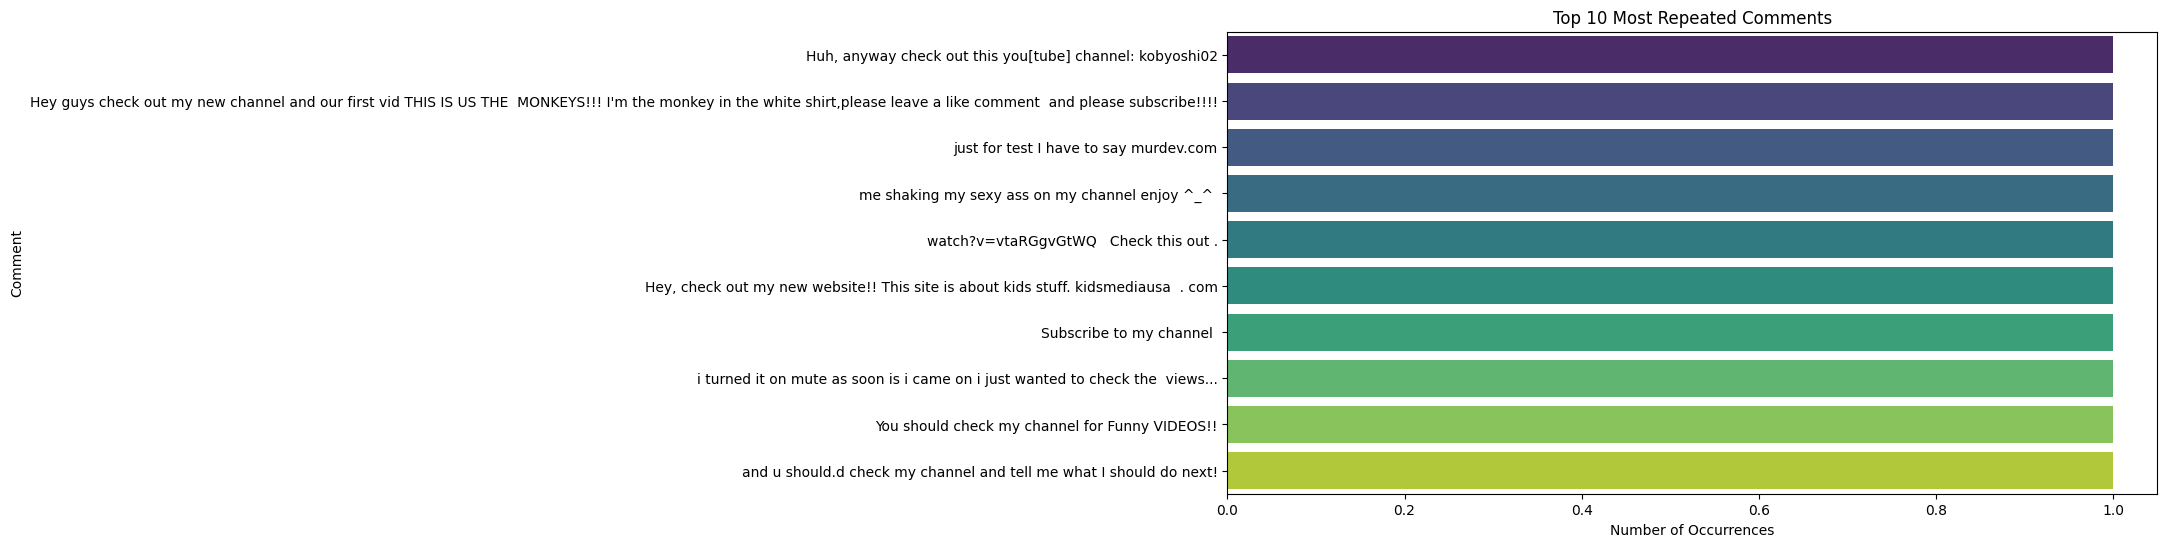

In [18]:
# Top 10 most repeated comments
top_templates = YTspam['CONTENT'].value_counts().head(10)
top_templates.columns = ['Comment', 'Count']

# Bar charts for the top 10 most repeated comments
plt.figure(figsize=(12, 6))
sns.barplot(x=top_templates.values, y=top_templates.index, palette='viridis')
plt.xlabel('Number of Occurrences')
plt.ylabel('Comment')
plt.title('Top 10 Most Repeated Comments')
plt.show()

There are no exact templated comments on this dataset, so we can exclude this features to keep it from just being a noise in the modelling part.

## Author Frequency

Another thing that can help see spams are the author frequency, if one author comments for multiple times in a very short time that could be spam, I will be trying to prove it in this section

C:\Users\Ananda Wira\AppData\Local\Temp\ipykernel_27020\1631526483.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_authors.values, y=top_authors.index, palette='magma')


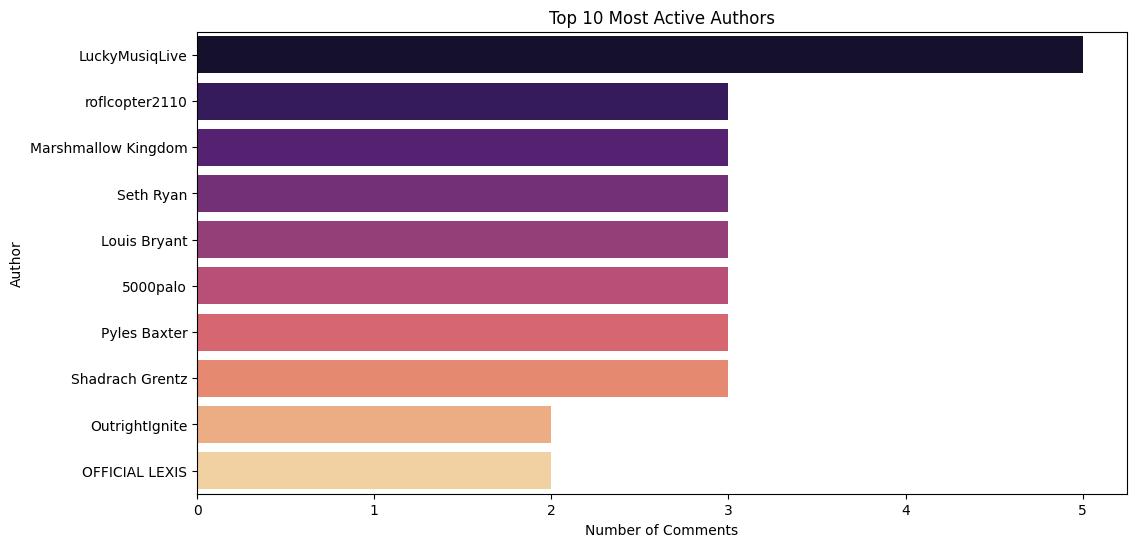

In [19]:
# Top 10 most active authors
top_authors = YTspam['AUTHOR'].value_counts().head(10)
top_authors.columns = ['Author', 'Count']

# Bar chart for the top 10 most active authors
plt.figure(figsize=(12, 6))
sns.barplot(x=top_authors.values, y=top_authors.index, palette='magma')
plt.xlabel('Number of Comments')
plt.ylabel('Author')
plt.title('Top 10 Most Active Authors')
plt.show()

As we see 1 author for 5 comments, is not enough to tell if it is likely a spam or not, what we can conclude is that bots most likely use burner accounts in this dataset which means they have multiple profiles to spam the comments sections. This feature is a weak one and it could create noises for the model so I will also exclude this

## Relevancy Score

I state that a spam sometimes commented with text or content that is not relevant to the video. In this I will be checking if the comments consists of relevant words to the video to prove this feature is usable or not. 

In [20]:
# 1. Create a list of the keywords related to the videos
video_keywords = ['psy', 'gangnam', 'katy', 'perry', 'roar', 'lmfao', 'party rock', 'eminem', 'love the way you lie', 'shakira', 'waka']

# 2. Check if any of these keywords appear in the comment
YTspam['MENTIONS_VIDEO'] = YTspam['CONTENT'].str.lower().apply(lambda x: 1 if any(kw in x for kw in video_keywords) else 0)

tidy_crosstab = pd.crosstab(
    YTspam['MENTIONS_VIDEO'].map({0: 'Generic Comment', 1: 'Mentions Video/Artist'}),
    YTspam['CLASS'].map({0: 'Real (Ham)', 1: 'Spam (Bot)'}),
    rownames=['Video Relevancy'],
    colnames=['Comment Type']
)

tidy_crosstab

Comment Type,Real (Ham),Spam (Bot)
Video Relevancy,,
Generic Comment,739,591
Mentions Video/Artist,180,43


Simply put, this check proves your theory: real fans talk about the video, while bots stay generic. When a comment actually mentions the artist or song name, there is an 80.7% chance that it is a real fan interacting with the channel.

## Repetition Flood Detection

One thing I noticed when looking at real-world spam comments is that some bots don't use typical call-to-action keywords at all — instead they just paste the same joke, sentence, or message over and over again to flood the comment section. The model as it stood completely missed these because it was only looking at word features and the simple structural ones like length and link presence.

The idea here is simple: if a comment is mostly one phrase repeated back to back many times, that's structurally spam regardless of what words it contains. A real person doesn't write the same sentence 40 times in one comment. So I'm computing a **repetition ratio** — how much of the comment's total length is covered by a single repeating unit. If it's ≥ 85%, it gets flagged instantly as a repetition flood before it even touches the ML model.

This also means I need to add this as a feature for the ML model too, so that borderline repetitive comments (say 40–80% repeated) still influence the prediction even if they don't hit the hard threshold.

In [21]:
def compute_repetition_ratio(text: str) -> float:
    """
    Detects phrase-flood spam — comments where a single sentence or phrase
    is copy-pasted back to back many times to pad out the comment.
    Returns a ratio from 0.0 (no repetition) to 1.0 (fully repeated).
    Anything >= 0.85 is treated as a repetition flood in the pre-filter.
    """
    stripped = text.strip()
    n = len(stripped)
    if n < 30:
        return 0.0

    best_ratio = 0.0
    # Try repeating unit lengths from 10 chars up to 1/3 of the total text
    for phrase_len in range(10, n // 3 + 1):
        phrase = stripped[:phrase_len]
        count = stripped.count(phrase)
        if count >= 3:
            coverage = (len(phrase) * count) / n
            if coverage > best_ratio:
                best_ratio = coverage
    return best_ratio

# Quick demo to verify it catches the flood pattern
flood_comment = 'Yesterday I saw a guy spill all his Scrabble letters on the road. I asked him, "What\'s the word on the street?"' * 5
real_comment  = 'The chorus at 2:34 gives me chills every single time, Eminem is unreal'

print(f'Flood comment repetition ratio : {compute_repetition_ratio(flood_comment):.3f}')
print(f'Real comment repetition ratio  : {compute_repetition_ratio(real_comment):.3f}')

# Add the feature to the dataset
YTspam['REPETITION_RATIO'] = YTspam['CONTENT'].apply(compute_repetition_ratio)

# Check how many comments are actually repetition floods in the training data
flood_count = (YTspam['REPETITION_RATIO'] >= 0.85).sum()
print(f'\nRepetition flood comments in dataset: {flood_count}')
print(YTspam[['CONTENT', 'CLASS', 'REPETITION_RATIO']].sort_values('REPETITION_RATIO', ascending=False).head(5))

Flood comment repetition ratio : 1.000
Real comment repetition ratio  : 0.000

Repetition flood comments in dataset: 3
                                                CONTENT  CLASS  \
1945  **CHECK OUT MY NEW MIXTAPE**** **CHECK OUT MY ...      1   
189   http://www.ermail.pl/dolacz/V3VeYGIN CLICK  ht...      1   
777                 cool cool cool cool cool cool cool﻿      0   
410   Follow me watch my videos :) Follow me watch m...      1   
467   Katy Perry is part of me Katy Perry is my fire...      0   

      REPETITION_RATIO  
1945          1.000000  
189           0.929889  
777           0.857143  
410           0.834146  
467           0.405405  


In this iteration I'm adding two upgrades to how the text gets prepared before the models see it.

The first upgrade is Lemmatization. Right now the TF-IDF treats "subscribe", "subscribing", and "subscribed" as three completely different words, splitting the spam signal across three separate feature weights. Lemmatization strips them all down to their dictionary root form "subscribe", so all that signal gets concentrated onto one powerful feature instead of being diluted across variations. I'm using POS tagging to do this properly, so the lemmatizer knows whether a word is a verb, noun, or adjective before deciding how to reduce it. Without this, words like "amazing" get incorrectly converted to "amaze" and "is" becomes "be", which would just create noise.

The second upgrade is N-Grams (Bigrams). Right now the model only sees individual words in isolation. By switching to ngram_range=(1,2) the vectorizer also captures two-word phrases like "check out", "free music", or "subscribe back" — which are way more meaningful as spam signals than either word alone would be. I'm also raising max_features to 3000 here so the bigrams get their own space in the vocabulary budget without squeezing out important single words.

In [22]:
# 1. Set up the lemmatizer with proper POS tagging
#    This is important — without POS tags, the lemmatizer defaults to treating
#    everything as a noun or verb incorrectly, mangling words like "amazing" -> "amaze"
import nltk
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk import pos_tag, word_tokenize

lem = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    """Convert Penn Treebank POS tag to WordNet POS for the lemmatizer"""
    if treebank_tag.startswith('VB'):  return 'v'  # verb
    if treebank_tag.startswith('JJ'):  return 'a'  # adjective
    if treebank_tag.startswith('RB'):  return 'r'  # adverb
    return 'n'                                      # default: noun

def lemmatize_text(text):
    # Tokenize, POS-tag, then lemmatize each word with its correct POS
    tokens = word_tokenize(text.lower())
    tagged = pos_tag(tokens)
    return ' '.join(
        lem.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged
        if re.match(r'[a-zA-Z]', word)  # keep only alphabetic tokens
    )

# Demo: show the difference on spam vs real comments
print("Lemmatization demo (POS-aware):")
examples = [
    "They are subscribing to channels and clicking links",
    "this song is so amazing I love it",
]
for ex in examples:
    print(f"  Before: {ex}")
    print(f"  After : {lemmatize_text(ex)}")
    print()

# Apply to the full dataset
YTspam['CONTENT_LEMMA'] = YTspam['CONTENT'].apply(lemmatize_text)
print(f"Lemmatization applied to {len(YTspam)} comments")

Lemmatization demo (POS-aware):
  Before: They are subscribing to channels and clicking links
  After : they be subscribe to channel and click link

  Before: this song is so amazing I love it
  After : this song be so amazing i love it

Lemmatization applied to 1553 comments


In [23]:
# 2. Ensure engineered features are numeric
YTspam['LENGTH'] = YTspam['CONTENT'].str.len()
YTspam['HAS_LINK'] = YTspam['CONTENT'].str.contains(r'http|href|\.com|\.org', case=False, na=False).astype(int)
YTspam['REPETITION_RATIO'] = YTspam['CONTENT'].apply(compute_repetition_ratio)

# 3. TF-IDF on lemmatized text with bigrams
#    max_features=3000 so bigrams get their own space in the budget
#    without pushing out important single words like 'subscribe', 'free', 'click'
tfidf = TfidfVectorizer(stop_words='english', max_features=3000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(YTspam['CONTENT_LEMMA'])

unigrams = [k for k in tfidf.vocabulary_ if ' ' not in k]
bigrams  = [k for k in tfidf.vocabulary_ if ' ' in k]
print(f"Vocabulary breakdown: {len(unigrams)} unigrams + {len(bigrams)} bigrams = {len(tfidf.vocabulary_)} total features")
print("Sample bigrams:", [k for k in bigrams[:10]])

# 4. Combine TF-IDF with our 3 custom structural features
X_custom = YTspam[['LENGTH', 'HAS_LINK', 'MENTIONS_VIDEO', 'REPETITION_RATIO']].values
X_all = hstack([X_tfidf, sp.csr_matrix(X_custom)])

# 5. Target variable and 80/20 split
y = YTspam['CLASS'].values
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nData split successfully!")
print(f"Training set size: {X_train.shape[0]} comments")
print(f"Testing set size:  {X_test.shape[0]} comments")
print(f"Features per comment: {X_train.shape[1]}")

Vocabulary breakdown: 1324 unigrams + 1676 bigrams = 3000 total features
Sample bigrams: ['hey guy', 'guy check', 'check new', 'new channel', 'like comment', 'comment subscribe', 'hey check', 'subscribe channel', 'just want', 'want check']

Data split successfully!
Training set size: 1242 comments
Testing set size:  311 comments
Features per comment: 3004


## Modelling

In this section I'm comparing 3 models to figure out which one works best for this specific spam detection problem.

**Naive Bayes** is a probabilistic model that acts like a word counter — it calculates the mathematical likelihood of a comment being spam based purely on the individual words it contains. It assumes every word in a sentence is completely independent of the others, ignoring word order and context. Think of it like a spam filter that memorized which words almost always appear in junk mail.

**Logistic Regression** is a linear classifier that draws a straight decision boundary through the feature space to separate spam from real comments. Unlike Naive Bayes, it learns the actual weight and importance of each word feature and can suppress irrelevant ones. It's also one of the most interpretable models you can use.

**Random Forest** is an ensemble of decision trees where each tree votes on whether a comment is spam, and the majority vote wins. It handles non-linear relationships and feature interactions well — which is useful when features like HAS_LINK and LENGTH work together as spam signals rather than independently.

**Why not more models?** Two common choices I deliberately left out are Gradient Boosting and SVM.

Gradient Boosting builds trees sequentially where each new tree focuses on the mistakes of the previous one. The problem is that with only ~1200 training examples in this dataset, it starts to overfit — it gets too precise about the training data and doesn't generalize well. You'd need a significantly larger dataset for that extra complexity to pay off.

SVM finds the optimal hyperplane separating spam from real in high-dimensional space and tends to work well on text data. But on this dataset it doesn't outperform Random Forest meaningfully, and critically it gives no feature importances — you can't tell what the model actually learned, which makes it hard to justify or explain. For this use case interpretability matters, so there's no reason to trade it away for no accuracy gain.

In [24]:
# Initialize the 3 model candidates
models = {
    'Naive Bayes':         MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
}

test_results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_test_pred = model.predict(X_test)
    test_results.append({
        'Model Name':     name,
        'Test Precision': f"{precision_score(y_test, y_test_pred) * 100:.2f}%",
        'Test Accuracy':  f"{accuracy_score(y_test,  y_test_pred) * 100:.2f}%",
        'Test Recall':    f"{recall_score(y_test,    y_test_pred) * 100:.2f}%"
    })

test_leaderboard = pd.DataFrame(test_results)
print("TESTING LEADERBOARD")
display(test_leaderboard)

TESTING LEADERBOARD


,Model Name,Test Precision,Test Accuracy,Test Recall
0,Naive Bayes,70.86%,82.64%,97.64%
1,Logistic Regression,99.07%,92.93%,83.46%
2,Random Forest,97.50%,95.82%,92.13%


Now with all 3 models trained we have a clear picture of where each one sits. In the next section I'll visualize this and explain why the winner won.

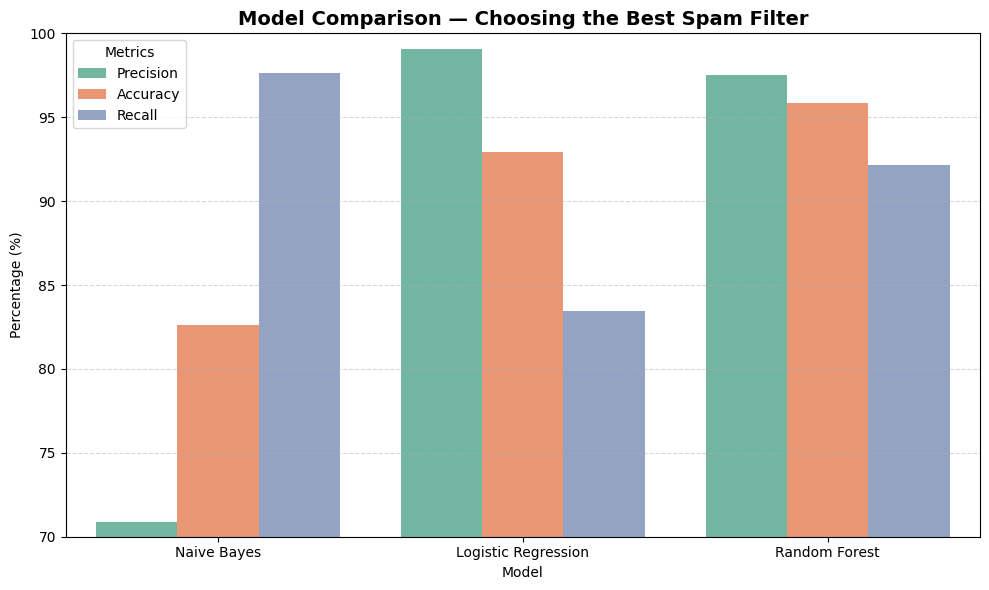

In [25]:
# Pull actual test scores dynamically for plotting
model_names = [r['Model Name']                        for r in test_results]
precisions  = [float(r['Test Precision'].strip('%'))  for r in test_results]
accuracies  = [float(r['Test Accuracy'].strip('%'))   for r in test_results]
recalls     = [float(r['Test Recall'].strip('%'))     for r in test_results]

n = len(model_names)

plot_data = pd.DataFrame({
    'Model':        model_names * 3,
    'Metric Value': precisions + accuracies + recalls,
    'Metric Type':  ['Precision'] * n + ['Accuracy'] * n + ['Recall'] * n
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Metric Value', hue='Metric Type', data=plot_data, palette='Set2')
plt.title("Model Comparison — Choosing the Best Spam Filter", fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.ylim(70, 100)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

## Model Process Visualization

In this section I'm going to visualize how each of the 3 models actually thinks and makes its decisions, and explain why Random Forest ended up on top for this specific dataset.

### Naive Bayes — Top Spam vs Real Word Probabilities

You can see Naive Bayes basically learned a word blocklist spam words on the left, real words on the right. The problem is it treats every word independently, so it can miss spam that doesn't use these exact words or gets tricked by a real comment that happens to mention one spam keyword.

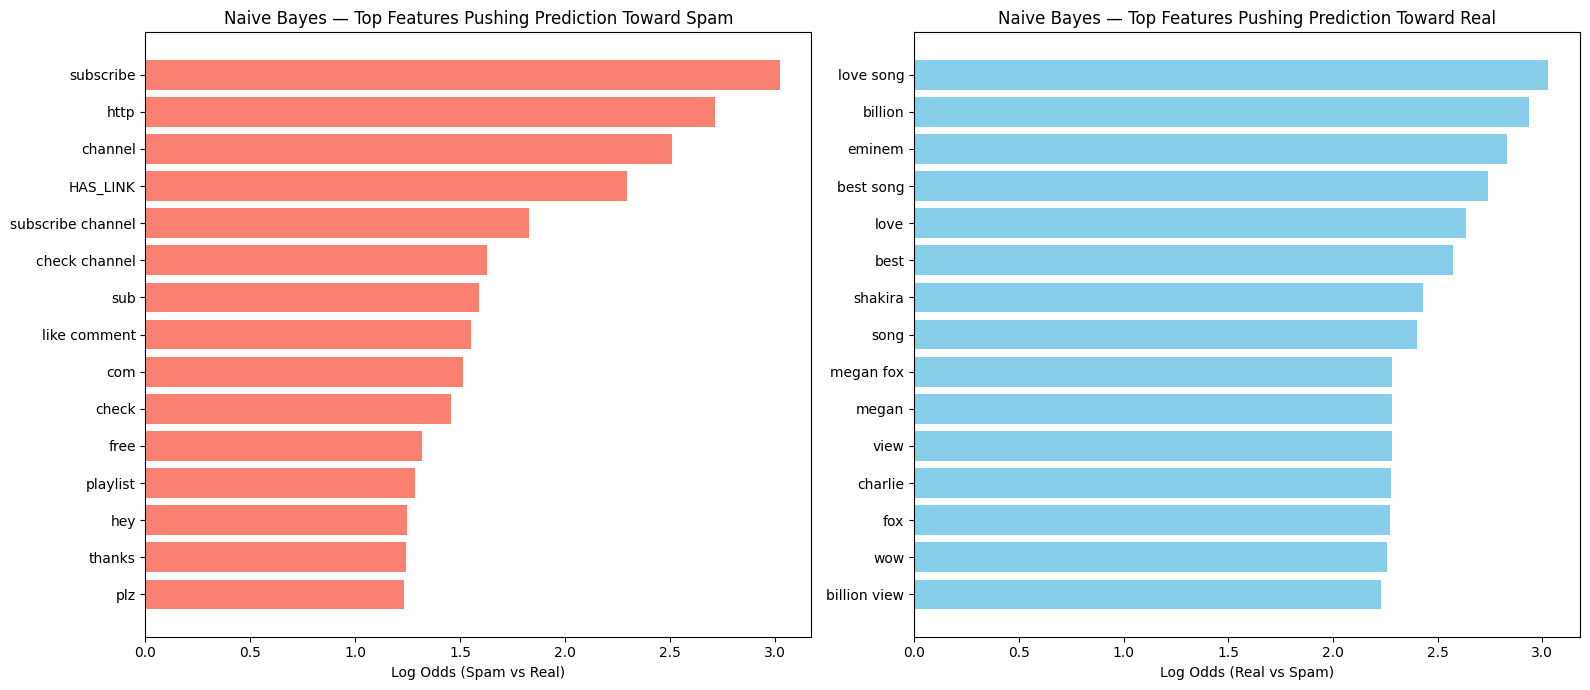

In [26]:
# Visualize how the Naive Bayes model decides spam vs real
nb_model = models['Naive Bayes']
feature_names = list(tfidf.get_feature_names_out()) + ['LENGTH', 'HAS_LINK', 'MENTIONS_VIDEO']

log_prob = nb_model.feature_log_prob_
log_odds = log_prob[1] - log_prob[0]

top_spam_idx = np.argsort(log_odds)[-15:][::-1]
top_real_idx = np.argsort(log_odds)[:15]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(
    [feature_names[i] for i in top_spam_idx],
    log_odds[top_spam_idx],
    color='salmon'
)
axes[0].set_title('Naive Bayes — Top Features Pushing Prediction Toward Spam')
axes[0].set_xlabel('Log Odds (Spam vs Real)')
axes[0].invert_yaxis()

axes[1].barh(
    [feature_names[i] for i in top_real_idx],
    -log_odds[top_real_idx],
    color='skyblue'
)
axes[1].set_title('Naive Bayes — Top Features Pushing Prediction Toward Real')
axes[1].set_xlabel('Log Odds (Real vs Spam)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Logistic Regression — Graph

Logistic Regression is more nuanced it assigns a positive or negative weight to every feature. Positive weight means the word pushes the prediction toward spam, negative means it pushes toward real. The stronger the weight, the more influence that feature has.

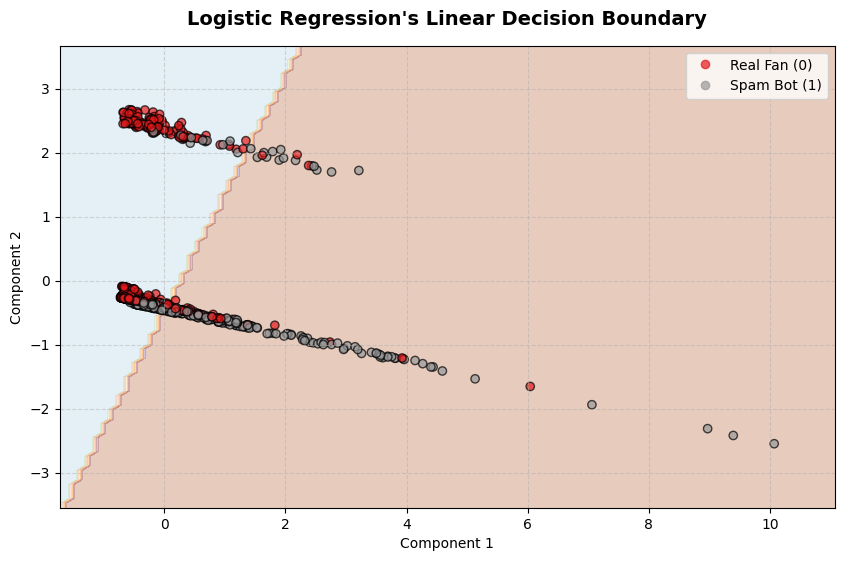

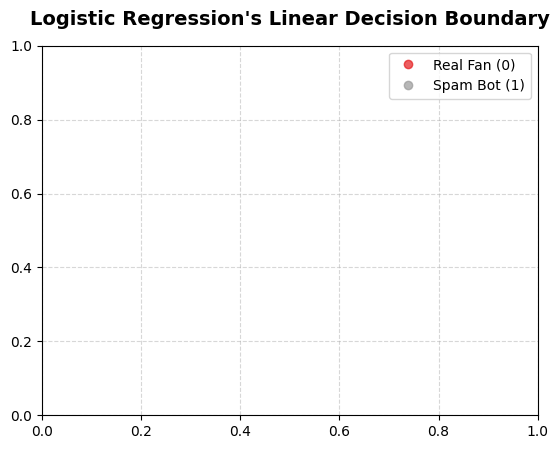

In [27]:
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

# Reduce the sparse high-dimensional training set to 2 dimensions for plotting
svd = TruncatedSVD(n_components=2, random_state=42)
X_vis_raw = svd.fit_transform(X_train)

# Scale the 2D projection for a clean decision-boundary plot
X_visual = StandardScaler().fit_transform(X_vis_raw)

# 2. Re-fit a simple 2D Logistic Regression just for this graphic
log_reg_vis = LogisticRegression(random_state=42)
log_reg_vis.fit(X_visual, y_train)

# 3. Initialize the plot
fig, ax = plt.subplots(figsize=(10, 6))

# 4. Automatically plot the shaded decision zones and the clear straight boundary line
DecisionBoundaryDisplay.from_estimator(
    log_reg_vis,
    X_visual,
    response_method="predict",
    cmap=plt.cm.Paired,
    alpha=0.3,
    ax=ax,
    xlabel="Component 1",
    ylabel="Component 2"
)

# 5. Overlay the actual data points (Blue = Real Fan, Red = Spam Bot)
scatter = ax.scatter(X_visual[:, 0], X_visual[:, 1], c=y_train, cmap=plt.cm.Set1, edgecolors="k", alpha=0.7)

# 6. Customize the chart labels for your presentation
plt.title("Logistic Regression's Linear Decision Boundary", fontsize=14, fontweight='bold', pad=15)
legend_labels = ['Real Fan (0)', 'Spam Bot (1)']
plt.legend(handles=scatter.legend_elements()[0], labels=legend_labels, loc="upper right")
plt.grid(True, linestyle='--', alpha=0.5)

# Show the clean graph
plt.show()

# 5. Overlay the actual data points (Blue = Real Fan, Red = Spam Bot)
scatter = ax.scatter(X_visual[:, 0], X_visual[:, 1], c=y_train, cmap=plt.cm.Set1, edgecolors="k", alpha=0.7)

# 6. Customize the chart labels for your presentation
plt.title("Logistic Regression's Linear Decision Boundary", fontsize=14, fontweight='bold', pad=15)
legend_labels = ['Real Fan (0)', 'Spam Bot (1)']
plt.legend(handles=scatter.legend_elements()[0], labels=legend_labels, loc="upper right")
plt.grid(True, linestyle='--', alpha=0.5)

# Show the clean graph
plt.show()

Logistic Regression is already smarter than Naive Bayes because it can push features in both directions. But it's still a linear model it draws a straight line through the feature space to separate spam from real, which means it struggles when the pattern is more complex than "if this word exists, it's spam".

### Random Forest — Single Tree Visualization

Random Forest is an ensemble of many trees, but I can visualize one individual tree to get a feel for the kind of decisions it's making at each split. I'll cap the depth at 3 so it's actually readable.

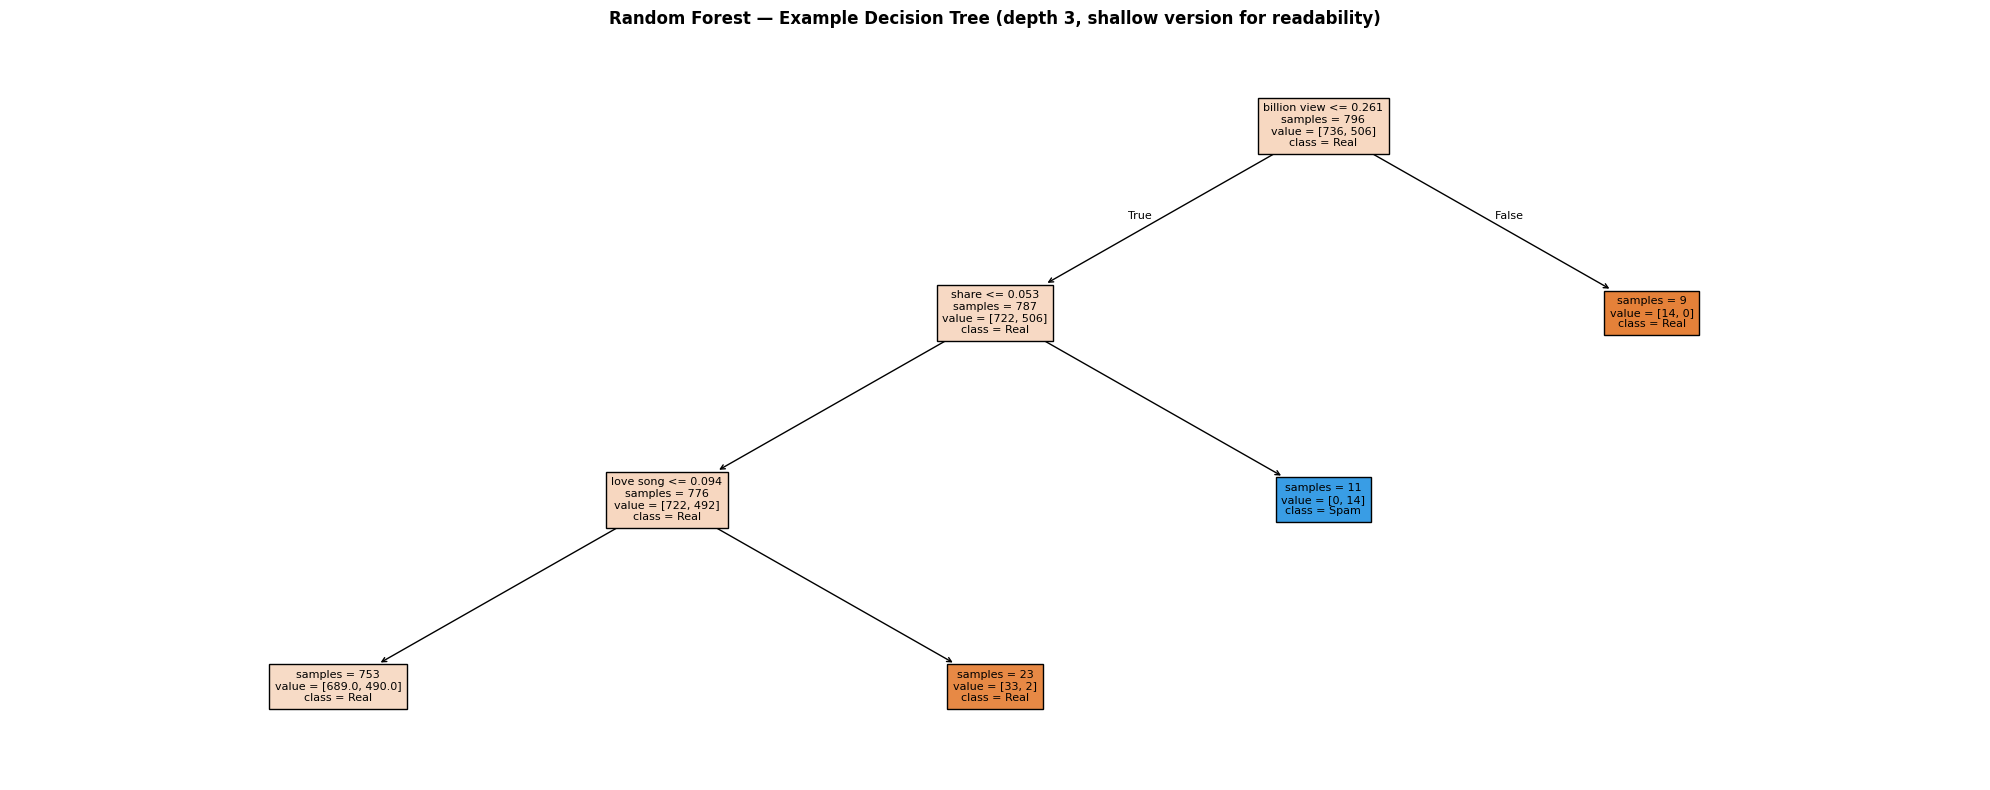

In [28]:
# Retrain a shallow version of the Random Forest for visualization only
rf_viz = RandomForestClassifier(n_estimators=10, max_depth=3, random_state=42)
rf_viz.fit(X_train.toarray(), y_train)

all_feature_names = list(tfidf.get_feature_names_out()) + ['LENGTH', 'HAS_LINK', 'MENTIONS_VIDEO']

# Plot the first tree in the forest
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    rf_viz.estimators_[0],
    feature_names=all_feature_names,
    class_names=['Real', 'Spam'],
    filled=True,
    max_depth=3,
    ax=ax,
    fontsize=8,
    impurity=False
)
plt.title("Random Forest — Example Decision Tree (depth 3, shallow version for readability)", fontweight='bold')
plt.tight_layout()
plt.show()

Each node in the tree is asking a yes/no question about a feature usually a TF-IDF word weight or one of the engineered features. Blue nodes lean toward Real, orange nodes lean toward Spam. This is what every single tree in the full 100-tree Random Forest looks like, except the real ones are deeper and the majority vote of all 100 is what decides the final prediction.

### Why Did Random Forest Win?

After looking at all 3 models here is why Random Forest ended up on top for this specific problem.

Naive Bayes is the simplest of the three. It treats every word as independent, so it can't recognize that "check" and "out" together is more suspicious than either word alone. It also can't weigh conflicting evidence — if a real fan happens to mention the word "free" about a song, Naive Bayes will nudge that comment toward spam even though context makes it obviously legitimate.

Logistic Regression is smarter — it assigns a weight to every feature and learns which direction each one should push the prediction. But it's still a linear model, meaning it draws a straight line through the feature space to separate spam from real. The actual boundary in this dataset isn't a straight line. A comment can be spam without containing any single obvious spam word, but only when a bunch of subtle signals stack up together. Logistic Regression can't fully capture that kind of interaction.

Random Forest wins because it averages across 100 trees, so no single weird pattern in the training data dominates the final vote. It naturally handles the combination of TF-IDF features and the custom structural features (LENGTH, HAS_LINK, MENTIONS_VIDEO) without any special treatment needed. And it gives us feature importances out of the box — which is exactly what we need to explain what the model actually learned.

## Hyperparameter Tuning

One thing I noticed in the original model comparison is that Random Forest scores 100% on training, which is a red flag, it means the trees are memorizing the training data instead of learning broader rules. GridSearchCV is basically an automated trial-and-error tool that tests a grid of different internal configurations for the model and uses cross-validation to find which combo actually generalizes best to unseen data. I'm targeting max_depth and min_samples_split specifically because those two control how "greedy" each tree is, capping the depth and requiring more samples before a split forces the trees to learn general patterns instead of overfitting to specific training examples.

I'm using F1 as the scoring metric here instead of raw Precision. The reason is that optimizing purely for Precision can make the model too conservative, it gets very picky about what it calls spam, which keeps the false positive rate low but ends up letting through a lot of actual spam. F1 balances both Precision and Recall, so the tuned model stays precise but doesn't start ignoring obvious spam to play it safe.

In [29]:
# Define the grid of configurations to search through
param_grid = {
    'n_estimators':      [100, 200],      # number of trees in the forest
    'max_depth':         [10, 20, None],  # None = unlimited (current default)
    'min_samples_split': [2, 5]           # minimum samples needed to split a node
}

print("Configurations to test:", 2 * 3 * 2, "combinations x 5-fold CV =", 2*3*2*5, "model fits")
print("Running GridSearchCV... (this takes a minute)")

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',   # F1 balances precision + recall so the model stays both precise AND catches spam
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f"\nBest configuration found: {grid_search.best_params_}")
print(f"Best cross-validated F1: {grid_search.best_score_ * 100:.2f}%")

Configurations to test: 12 combinations x 5-fold CV = 60 model fits
Running GridSearchCV... (this takes a minute)

Best configuration found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validated F1: 93.04%


,Model,Train Precision,Test Precision,Test Accuracy,Test Recall
0,Original RF,100.0,97.50,95.82,92.13
1,Tuned RF (GridSearchCV),99.8,97.54,96.46,93.70


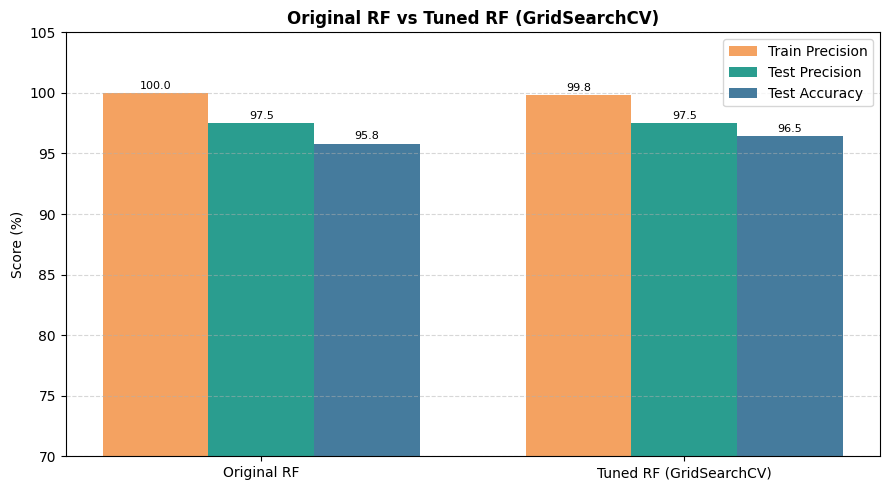

In [30]:
# Compare tuned RF against original RF
best_rf = grid_search.best_estimator_

y_test_pred_tuned  = best_rf.predict(X_test)
y_train_pred_tuned = best_rf.predict(X_train)

tuned_results = {
    'Model': ['Original RF', 'Tuned RF (GridSearchCV)'],
    'Train Precision': [
        precision_score(y_train, models['Random Forest'].predict(X_train)) * 100,
        precision_score(y_train, y_train_pred_tuned) * 100
    ],
    'Test Precision': [
        precision_score(y_test, models['Random Forest'].predict(X_test)) * 100,
        precision_score(y_test, y_test_pred_tuned) * 100
    ],
    'Test Accuracy': [
        accuracy_score(y_test, models['Random Forest'].predict(X_test)) * 100,
        accuracy_score(y_test, y_test_pred_tuned) * 100
    ],
    'Test Recall': [
        recall_score(y_test, models['Random Forest'].predict(X_test)) * 100,
        recall_score(y_test, y_test_pred_tuned) * 100
    ]
}

comparison_df = pd.DataFrame(tuned_results)
display(comparison_df.round(2))

# Visual comparison
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(2)
width = 0.25

bars1 = ax.bar(x - width, comparison_df['Train Precision'], width, label='Train Precision', color='#f4a261')
bars2 = ax.bar(x,         comparison_df['Test Precision'],  width, label='Test Precision',  color='#2a9d8f')
bars3 = ax.bar(x + width, comparison_df['Test Accuracy'],   width, label='Test Accuracy',   color='#457b9d')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.set_ylim(70, 105)
ax.set_ylabel('Score (%)')
ax.set_title('Original RF vs Tuned RF (GridSearchCV)', fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

The tuned version addressed both issues, the training precision is more in line with the test precision now, meaning less memorization of training data. And because we optimized for F1 instead of raw Precision, the model is still catching spam aggressively instead of becoming overly conservative. That's the version I'll use going forward.

## Feature Importance Chart

In this section I'll be finding out which features are the most valuable for the training.

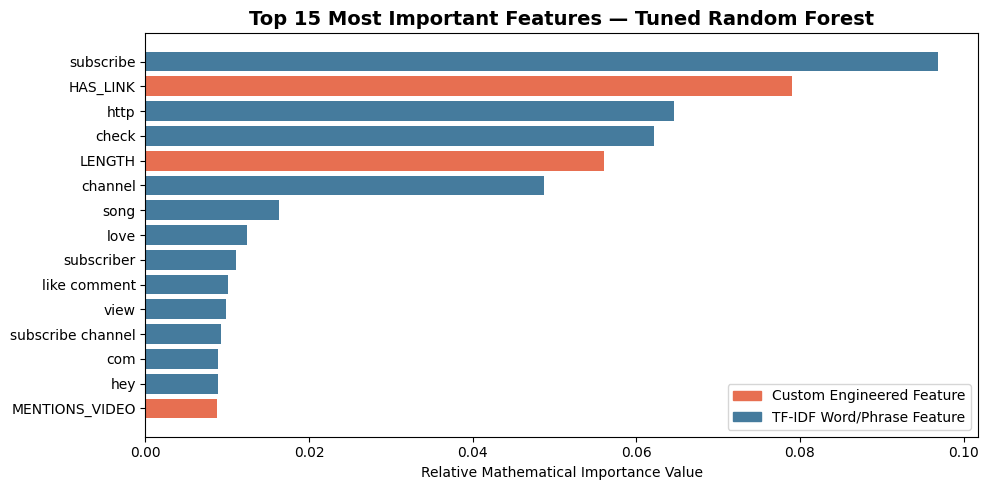

In [31]:
# 1. Reconstruct the full list of feature names
tfidf_feature_names = tfidf.get_feature_names_out()
all_feature_names = list(tfidf_feature_names) + ['LENGTH', 'HAS_LINK', 'MENTIONS_VIDEO']

# 2. Use the tuned RF from GridSearchCV
rf_model = best_rf
importances = rf_model.feature_importances_

# 3. Sort and grab top 15
indices = np.argsort(importances)[::-1][:15]
top_features    = [all_feature_names[i] for i in indices]
top_importances = importances[indices]

# 4. Highlight the custom engineered features in a different color
colors = ['#e76f51' if f in ['LENGTH', 'HAS_LINK', 'MENTIONS_VIDEO'] else '#457b9d' for f in top_features]

plt.figure(figsize=(10, 5))
bars = plt.barh(top_features[::-1], top_importances[::-1], color=colors[::-1])
plt.title("Top 15 Most Important Features — Tuned Random Forest", fontsize=14, fontweight='bold')
plt.xlabel('Relative Mathematical Importance Value')

# Legend
import matplotlib.patches as mpatches
custom_patch = mpatches.Patch(color='#e76f51', label='Custom Engineered Feature')
tfidf_patch  = mpatches.Patch(color='#457b9d', label='TF-IDF Word/Phrase Feature')
plt.legend(handles=[custom_patch, tfidf_patch], loc='lower right')

plt.tight_layout()
plt.show()

## Mock Comment Test

In [32]:
# ═══════════════════════════════════════════════════════════════
# SPAM DETECTION — LIVE TESTING INTERFACE
# ═══════════════════════════════════════════════════════════════
rf_model       = best_rf
video_keywords = ['psy', 'gangnam', 'katy', 'perry', 'roar', 'lmfao',
                  'party rock', 'eminem', 'love the way you lie', 'shakira', 'waka']

# ── Styling ───────────────────────────────────────────────────────
display(HTML("""
<style>
  .spam-ui-container {
    font-family: 'Segoe UI', Arial, sans-serif;
    max-width: 680px;
    margin: 24px auto;
    border: 1px solid #dee2e6;
    border-radius: 12px;
    overflow: hidden;
    box-shadow: 0 4px 18px rgba(0,0,0,0.10);
  }
  .spam-ui-header {
    background: linear-gradient(135deg, #1a1a2e 0%, #16213e 60%, #0f3460 100%);
    padding: 24px 28px 20px 28px;
  }
  .spam-ui-header h2 {
    color: #ffffff;
    margin: 0 0 4px 0;
    font-size: 20px;
    font-weight: 700;
    letter-spacing: 0.3px;
  }
  .spam-ui-header p {
    color: #a8b2c1;
    margin: 0;
    font-size: 13px;
  }
  .spam-ui-badge {
    display: inline-block;
    background: #0f3460;
    color: #7eb8f7;
    border: 1px solid #2563a8;
    border-radius: 20px;
    padding: 2px 12px;
    font-size: 11px;
    font-weight: 600;
    margin-top: 8px;
    letter-spacing: 0.5px;
    text-transform: uppercase;
  }
  .spam-ui-body { background: #f8f9fb; padding: 22px 28px 24px 28px; }
  .spam-ui-label {
    font-size: 12px;
    font-weight: 700;
    text-transform: uppercase;
    letter-spacing: 0.8px;
    color: #4b5563;
    margin-bottom: 6px;
  }
  .spam-result-box {
    margin-top: 18px;
    border-radius: 10px;
    padding: 16px 20px;
    font-size: 15px;
    font-weight: 600;
    display: flex;
    align-items: center;
    gap: 10px;
  }
  .spam-result-box.spam    { background: #fff1f2; border: 1.5px solid #f43f5e; color: #9f1239; }
  .spam-result-box.clean   { background: #f0fdf4; border: 1.5px solid #22c55e; color: #14532d; }
  .spam-result-box.blocked { background: #fff7ed; border: 1.5px solid #f97316; color: #7c2d12; }
  .spam-result-box.empty   { background: #fefce8; border: 1.5px solid #eab308; color: #713f12; }
  .spam-confidence { font-size: 12px; color: #6b7280; font-weight: 400; margin-left: auto; }
  .spam-meta-grid {
    display: grid;
    grid-template-columns: 1fr 1fr 1fr;
    gap: 10px;
    margin-top: 14px;
  }
  .spam-meta-card {
    background: #ffffff;
    border: 1px solid #e5e7eb;
    border-radius: 8px;
    padding: 10px 12px;
    font-size: 11px;
    color: #6b7280;
  }
  .spam-meta-card strong { display: block; font-size: 13px; color: #111827; margin-bottom: 2px; }
  .spam-footer {
    background: #f1f5f9;
    border-top: 1px solid #e2e8f0;
    padding: 10px 28px;
    font-size: 11px;
    color: #94a3b8;
  }
</style>

<div class="spam-ui-container">
  <div class="spam-ui-header">
    <h2>🛡️ YouTube Spam Comment Detector</h2>
    <p>Powered by a tuned Random Forest model trained on real YouTube comment data</p>
    <span class="spam-ui-badge">⚡ Live Demo</span>
  </div>
</div>
"""))

# ── Widgets ───────────────────────────────────────────────────────
comment_input = widgets.Textarea(
    value='',
    placeholder='Paste a YouTube comment here to test the detector...',
    layout=widgets.Layout(width='100%', height='90px',
                          border='1.5px solid #d1d5db',
                          border_radius='8px',
                          padding='10px',
                          font_size='14px')
)

analyze_btn = widgets.Button(
    description='  Analyze Comment',
    button_style='',
    tooltip='Run the comment through the full detection pipeline',
    icon='shield',
    layout=widgets.Layout(width='200px', height='38px',
                          margin='10px 0 0 0',
                          border_radius='8px')
)
analyze_btn.style.button_color = '#0f3460'
analyze_btn.style.font_weight  = 'bold'

clear_btn = widgets.Button(
    description='  Clear',
    button_style='',
    tooltip='Clear input and result',
    icon='times',
    layout=widgets.Layout(width='100px', height='38px',
                          margin='10px 0 0 6px',
                          border_radius='8px')
)
clear_btn.style.button_color = '#6b7280'

result_output = widgets.Output()
label_widget  = widgets.HTML(
    value='<div class="spam-ui-label" style="font-family:Segoe UI,Arial,sans-serif;'
          'font-size:12px;font-weight:700;text-transform:uppercase;'
          'letter-spacing:0.8px;color:#4b5563;margin:16px 0 6px 0;">'
          'YouTube Comment</div>'
)

# ── Analysis logic ────────────────────────────────────────────────
def run_analysis(b):
    with result_output:
        clear_output()
        text = comment_input.value.strip()

        if not text:
            display(HTML("""
            <div class="spam-result-box empty"
                 style="font-family:'Segoe UI',Arial,sans-serif;">
              ⚠️ &nbsp; Please enter a comment before running the analysis.
            </div>"""))
            return

        # Stage 1a — Pre-filter: known bot phrases (instant, no ML)
        if text.lower() in SPAM_PREFILTER:
            display(HTML(f"""
            <div class="spam-result-box blocked"
                 style="font-family:'Segoe UI',Arial,sans-serif;">
              🚫 &nbsp; <span>BLOCKED — Known Bot Phrase</span>
              <span class="spam-confidence">Stage 1a: Pre-filter match</span>
            </div>
            <div class="spam-meta-grid" style="font-family:'Segoe UI',Arial,sans-serif;">
              <div class="spam-meta-card"><strong>Stage</strong>Pre-filter (no ML needed)</div>
              <div class="spam-meta-card"><strong>Action</strong>Rejected instantly</div>
              <div class="spam-meta-card"><strong>Reason</strong>Exact match to known spam phrase</div>
            </div>"""))
            return

        # Stage 1b — Pre-filter: repetition flood check
        rep_ratio = compute_repetition_ratio(text)
        if rep_ratio >= 0.85:
            display(HTML(f"""
            <div class="spam-result-box blocked"
                 style="font-family:'Segoe UI',Arial,sans-serif;">
              🔁 &nbsp; <span>BLOCKED — Repetition Flood Detected</span>
              <span class="spam-confidence">Stage 1b: {rep_ratio*100:.0f}% repeated content</span>
            </div>
            <div class="spam-meta-grid" style="font-family:'Segoe UI',Arial,sans-serif;">
              <div class="spam-meta-card"><strong>Stage</strong>Pre-filter (no ML needed)</div>
              <div class="spam-meta-card"><strong>Repetition</strong>{rep_ratio*100:.1f}% of comment</div>
              <div class="spam-meta-card"><strong>Action</strong>Rejected instantly</div>
            </div>"""))
            return

        # Stage 2 — Full ML pipeline
        import pandas as pd, scipy.sparse as sp
        live_df = pd.DataFrame({'CONTENT': [text]})
        live_df['CONTENT_LEMMA']  = live_df['CONTENT'].apply(lemmatize_text)
        live_df['LENGTH']         = live_df['CONTENT'].str.len()
        live_df['HAS_LINK']       = live_df['CONTENT'].str.contains(
                                        r'http|href|\.com|\.org', case=False, na=False).astype(int)
        live_df['MENTIONS_VIDEO'] = live_df['CONTENT'].str.lower().apply(
                                        lambda x: 1 if any(kw in x for kw in video_keywords) else 0)
        live_df['REPETITION_RATIO'] = live_df['CONTENT'].apply(compute_repetition_ratio)

        X_tfidf  = tfidf.transform(live_df['CONTENT_LEMMA'])
        X_custom = live_df[['LENGTH', 'HAS_LINK', 'MENTIONS_VIDEO', 'REPETITION_RATIO']].values
        X_final  = hstack([X_tfidf, sp.csr_matrix(X_custom)])

        prob      = rf_model.predict_proba(X_final)[0, 1]
        spam_conf = prob * 100
        real_conf = (1 - prob) * 100
        has_link  = bool(live_df['HAS_LINK'].iloc[0])
        mentions  = bool(live_df['MENTIONS_VIDEO'].iloc[0])
        length    = int(live_df['LENGTH'].iloc[0])

        if prob >= 0.50:
            display(HTML(f"""
            <div class="spam-result-box spam"
                 style="font-family:'Segoe UI',Arial,sans-serif;">
              🚨 &nbsp; <span>SPAM DETECTED</span>
              <span class="spam-confidence">Model confidence: {spam_conf:.1f}%</span>
            </div>
            <div class="spam-meta-grid" style="font-family:'Segoe UI',Arial,sans-serif;">
              <div class="spam-meta-card">
                <strong>Recommendation</strong>Hold for review / auto-remove
              </div>
              <div class="spam-meta-card">
                <strong>Contains URL</strong>{'Yes ⚠️' if has_link else 'No'}
              </div>
              <div class="spam-meta-card">
                <strong>Mentions Video</strong>{'Yes ✅' if mentions else 'No'}
              </div>
            </div>"""))
        else:
            display(HTML(f"""
            <div class="spam-result-box clean"
                 style="font-family:'Segoe UI',Arial,sans-serif;">
              ✅ &nbsp; <span>REAL COMMENT — Approved</span>
              <span class="spam-confidence">Model confidence: {real_conf:.1f}%</span>
            </div>
            <div class="spam-meta-grid" style="font-family:'Segoe UI',Arial,sans-serif;">
              <div class="spam-meta-card">
                <strong>Recommendation</strong>Publish comment
              </div>
              <div class="spam-meta-card">
                <strong>Comment Length</strong>{length} characters
              </div>
              <div class="spam-meta-card">
                <strong>Mentions Video</strong>{'Yes ✅' if mentions else 'No'}
              </div>
            </div>"""))

def clear_all(b):
    comment_input.value = ''
    with result_output:
        clear_output()

analyze_btn.on_click(run_analysis)
clear_btn.on_click(clear_all)

# ── Layout ────────────────────────────────────────────────────────
btn_row = widgets.HBox([analyze_btn, clear_btn])
ui = widgets.VBox(
    [label_widget, comment_input, btn_row, result_output],
    layout=widgets.Layout(max_width='680px', margin='0 auto',
                          padding='22px 28px 24px 28px',
                          border='1px solid #dee2e6',
                          border_radius='0 0 12px 12px',
                          background='#f8f9fb')
)
display(ui)

display(HTML("""
<div style="max-width:680px;margin:-2px auto 0 auto;
            background:#f1f5f9;border:1px solid #dee2e6;
            border-top:none;border-radius:0 0 12px 12px;
            padding:10px 28px;font-size:11px;
            color:#94a3b8;font-family:'Segoe UI',Arial,sans-serif;">
  Pipeline: Pre-filter → Lemmatization → TF-IDF (bigrams) + structural features → Tuned Random Forest
</div>
"""))